### Prediction Notebook - Fragment-Based Molecular Generation

Using pre-trained models downloaded from HuggingFace, this notebook extracts fragments from arbitrary SMILES and generates new molecules containing those fragments.

#### Models
- **T5Chem (RFFMG)**: T5-based Transformer model (run in `t5chem` environment)
- **SAFE-GPT**: GPT-based model using SAFE representation (run in `safe` environment)

#### Fragmentation Methods
- **BRICS**: Chemically meaningful fragmentation via BRICS decomposition
- **RC_CMS**: Random-cut fragmentation (SP3-SP3 bonds, ring-ring connections, etc.)

### 0. Install Dependencies

Select the appropriate environment for the model you want to use.

In [12]:
# --- T5Chem environment ---

# Create virtual environment
!conda create -n t5chem python=3.12 -y

# Install packages
!conda run -n t5chem pip install -r requirements/t5chem_requirements.txt
!conda run -n t5chem pip install -e .

# Register as Jupyter kernel
!conda run -n t5chem pip install ipykernel
!conda run -n t5chem python -m ipykernel install --user --name t5chem --display-name "t5chem"

print("✅ Switch the kernel to 't5chem' before running the next cell")

UnboundLocalError: cannot access local variable 'child' where it is not associated with a value

--- Logging error ---
Traceback (most recent call last):
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/IPython/utils/_process_posix.py", line 125, in system
    child = pexpect.spawn(self.sh, args=['-c', cmd])  # Vanilla Pexpect
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/pexpect/pty_spawn.py", line 205, in __init__
    self._spawn(command, args, preexec_fn, dimensions)
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/pexpect/pty_spawn.py", line 303, in _spawn
    self.ptyproc = self._spawnpty(self.args, env=self.env,
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/pexpect/pty_spawn.py", line 315, in _spawnpty
    return ptyprocess.PtyProcess.spawn(args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-p

In [2]:
# --- SAFE environment ---

# Create virtual environment
!conda create -n safe python=3.12 -y

# Install packages
!conda run -n safe pip install -r requirements/safe_requirements.txt
!conda run -n safe pip install -e .

# Register as Jupyter kernel
!conda run -n safe pip install ipykernel
!conda run -n safe python -m ipykernel install --user --name safe --display-name "safe"

print("✅ Switch the kernel to 'safe' before running the next cell")

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /home/sato/miniconda3/envs/safe

  added / updated specs:
    - python=3.12


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ld_impl_linux-64-2.44      |       h9e0c5a2_3         725 KB
    openssl-3.5.5              |       h1b28b03_0         5.5 MB
    sqlite-3.51.2              |       h3e8d24a_0         1.2 MB
    tzdata-2026a               |       he532380_0         117 KB
    xz-5.8.2                   |       h448239c_0         621 KB
    ------------------------------------------------------------
                                           Total:         8.2 MB

The following NEW packages will be INSTALLED:

  _libgcc_mutex      pkgs/main/linux-64::_libgcc_mutex-0.1-main 
  _openmp_mutex      pkgs/main/linux-64::_openmp_mutex-5.1-1_g

## 1. Download Models

Download pre-trained models from HuggingFace Hub (`sato-akinori/FFMG`).  
For private repositories, log in beforehand with `huggingface-cli login`.

In [1]:
import os
import glob
import subprocess
from huggingface_hub import snapshot_download

# Download models from HuggingFace
snapshot_download(
    repo_id='sato-akinori/FFMG',
    allow_patterns='models/*',
    local_dir='.'
)

# Extract zip files
for zip_file in glob.glob('models/**/*.zip', recursive=True):
    subprocess.run(['unzip', '-o', zip_file, '-d', os.path.dirname(zip_file)], check=True)
    os.remove(zip_file)


# Download pretrained safe-gpt model
snapshot_download(
    repo_id='datamol-io/safe-gpt',
    local_dir='models/safe_gpt/pretrained'
)

print('Model download complete.')

/home/sato/miniconda3/envs/safe/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 6 files:   0%|          | 0/6 [00:05<?, ?it/s]


KeyboardInterrupt: 

## 2. Configuration

Configure the fragmentation method, generation parameters, etc.

In [4]:
# ========================================
# Configuration (modify as needed)
# ========================================
FRAG_METHOD = 'rc_cms'    # 'brics' or 'rc_cms'
N_SAMPLES   = 10         # Number of molecules to generate
NUM_BEAMS   = 10         # Number of beams for beam search
MAX_LENGTH  = 200        # Maximum sequence length

# Model paths
T5CHEM_MODEL_PATH = f'models/t5chem/trained/rffmg/{FRAG_METHOD}/best_model/'
SAFE_MODEL_PATH   = f'models/safe_gpt/trained/safe/{FRAG_METHOD}/best_model/'
# SAFE_MODEL_PATH   = f'models/safe_gpt/pretrained/'

## 3. Import Libraries and Helper Functions

In [2]:
import sys
import os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

from func.fragmentation import (
    BRICSFragmentize,
    RandomFragmentize,
    PostProcessSelectFrags,
)


def fragmentize_smiles(smiles, frag_method='brics', ratio=0.6, big_ring_thres=7, seed=42):
    """
    Fragmentize a SMILES string.

    Returns:
        pass_frags: Fragment SMILES (R-groups on rings trimmed)
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')

    if frag_method == 'brics':
        frags = BRICSFragmentize(mol, returnSmiles=False)
        trim_r_on_ring = False
    elif frag_method == 'rc_cms':
        frags = RandomFragmentize(
            mol, returnSmiles=False,
            bigRingThres=big_ring_thres, rseed=seed, ratio=ratio
        )
        trim_r_on_ring = True
    else:
        raise ValueError(f'Unknown method: {frag_method}')

    if frags is None:
        return None

    pass_frags, _ = PostProcessSelectFrags(
        frags,
        smallCarbonFilter=True,
        trimRgroupOnRing=trim_r_on_ring,
        uniquenize=(frag_method != 'brics'),
    )
    return pass_frags


def draw_mols(smiles_list, legends=None, mols_per_row=4, img_size=(300, 300)):
    """Draw molecules from a list of SMILES strings."""
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    mols = [m for m in mols if m is not None]
    if not mols:
        print('No valid molecules to draw.')
        return
    if legends is None:
        legends = [Chem.MolToSmiles(m) for m in mols]
    img = Draw.MolsToGridImage(
        mols[:12], molsPerRow=mols_per_row, subImgSize=img_size, legends=legends[:12]
    )
    display(img)


def generate_t5chem(fragments, model_path, num_beams, n_samples):
    """Generate molecules using T5Chem and return a list of SMILES."""
    import subprocess, tempfile

    with tempfile.TemporaryDirectory() as tmpdir:
        with open(os.path.join(tmpdir, 'test.source'), 'w') as f:
            f.write(fragments + '\n')
        with open(os.path.join(tmpdir, 'test.target'), 'w') as f:
            f.write('C\n')

        pred_file = os.path.join(tmpdir, 'predictions.csv')
        cmd = [
            't5chem', 'predict',
            '--data_dir', tmpdir,
            '--model_dir', model_path,
            '--prediction', pred_file,
            '--num_beams', str(num_beams),
            '--num_preds', str(n_samples),
            '--batch_size', '1',
        ]

        print(f'Running: {" ".join(cmd)}')
        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            print(f'Error: {result.stderr}')
            return None

        df = pd.read_csv(pred_file)
        display(df)
        smiles = [
            df.iloc[0, i]
            for i in range(1, min(n_samples + 1, len(df.columns)))
            if isinstance(df.iloc[0, i], str)
        ]
        return smiles


def generate_safe(fragments, safe_generator, n_samples, random_seed, max_length):
    """Generate molecules using SAFE-GPT and return a list of SMILES."""
    frag_list = fragments.split('.')

    if len(frag_list) == 1:
        print(f'Single fragment -> scaffold decoration')
        gen_mols = safe_generator.scaffold_decoration(
            scaffold=fragments,
            n_samples_per_trial=n_samples,
            n_trials=1,
            do_sample=False,
            random_seed=random_seed,
            max_length=max_length,
        )
    else:
        print(f'Multiple fragments -> scaffold morphing')
        gen_mols = safe_generator.scaffold_morphing(
            side_chains=frag_list,
            n_samples_per_trial=n_samples,
            n_trials=1,
            random_seed=random_seed,
            max_length=max_length,
        )

    # Post-process: greedy decoration for remaining wildcards
    gen_mols = ['safe_invalid' if m is None else m for m in gen_mols]
    processed = []
    for gen_mol in gen_mols:
        if '*' in gen_mol and len(gen_mol.split('.')) == 1:
            try:
                gen_mol = safe_generator.scaffold_decoration(
                    scaffold=gen_mol, n_samples_per_trial=1,
                    how='greedy', do_sample=False,
                    random_seed=random_seed, max_length=max_length
                )[0]
            except Exception:
                gen_mol = 'safe_invalid'
        if gen_mol is None or len(gen_mol.split('.')) != 1:
            gen_mol = 'safe_invalid'
        processed.append(gen_mol)

    valid = [s for s in processed if s not in ('safe_invalid', 'error')]
    print(f'Generated: {len(processed)}, Valid: {len(valid)}')

    df = pd.DataFrame({'SMILES': processed})
    display(df)
    return valid


def load_safe_model(model_path):
    """Load SAFE-GPT model and return the generator."""
    import safe
    from safe.sample import SAFEDesign
    from safe.tokenizer import SAFETokenizer
    from safe.trainer.model import SAFEDoubleHeadsModel
    import torch

    model = SAFEDoubleHeadsModel.from_pretrained(model_path)
    tokenizer = SAFETokenizer.from_pretrained(model_path)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    print(f'Using device: {device}')
    return SAFEDesign(model=model, tokenizer=tokenizer)


print('Library import complete.')

Library import complete.


/home/sato/miniconda3/envs/t5chem/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Input SMILES and Fragmentation

Enter an arbitrary SMILES and perform fragmentation.  
Modify `input_smiles` to try different molecules.

In [ ]:
# ========================================
# Input SMILES (modifiable)
# ========================================
input_smiles = 'CC(C)Cc1ccc(C(C)C(=O)O)cc1'  # Ibuprofen

# Validate and canonicalize SMILES
mol = Chem.MolFromSmiles(input_smiles)
assert mol is not None, 'Invalid SMILES. Please enter a valid SMILES string.'
canonical_smi = Chem.MolToSmiles(mol)
print(f'Input molecule (canonical SMILES): {canonical_smi}')

# Fragmentation
pass_frags = fragmentize_smiles(canonical_smi, frag_method=FRAG_METHOD)

if pass_frags is None:
    print('This molecule cannot be fragmented. Try a different SMILES or method.')
else:
    print(f'\n--- Fragmentation Results ---')
    print(f'Method: {FRAG_METHOD}')
    print(f'Fragments: {pass_frags}')
    print(f'Number of fragments: {len(pass_frags.split("."))}')

    frag_smiles = pass_frags.split('.')
    draw_mols(
        [canonical_smi] + frag_smiles,
        legends=['Input molecule'] + [f'Fragment {i+1}' for i in range(len(frag_smiles))]
    )

---
## 5. Molecule Generation from Fragmented Input

Generate molecules from the fragments obtained in Section 4.

### 5a. T5Chem (RFFMG) Generation

**Note**: This section should be run in the `t5chem` environment.
```bash
conda activate t5chem
```

In [ ]:
assert pass_frags is not None, 'Fragmentation failed. Please check Section 4.'

print(f'Input fragments: {pass_frags}')
smiles = generate_t5chem(pass_frags, T5CHEM_MODEL_PATH, NUM_BEAMS, N_SAMPLES)
if smiles:
    draw_mols(smiles)

### 5b. SAFE-GPT Generation

**Note**: This section should be run in the `safe` environment.
```bash
conda activate safe
```

In [ ]:
assert pass_frags is not None, 'Fragmentation failed. Please check Section 4.'

safe_generator = load_safe_model(SAFE_MODEL_PATH)

RANDOM_SEED = 0

print(f'Input fragments: {pass_frags}')
valid_smiles = generate_safe(pass_frags, safe_generator, N_SAMPLES, RANDOM_SEED, MAX_LENGTH)
if valid_smiles:
    draw_mols(valid_smiles)

---
## 6. Generate Molecules from Custom Fragments

Instead of fragmenting a molecule first, you can directly specify fragment SMILES and generate molecules.

**Fragment format:**
- Use `[*]` or `*` to mark attachment points
- Separate multiple fragments with `.` (dot)
- Single fragment → scaffold decoration (fills attachment points)
- Multiple fragments → scaffold morphing (combines fragments into a molecule)

**Examples:**
- Single fragment: `c1ccc([*])cc1` (benzene with one attachment point)
- Multiple fragments: `[*]c1ccccc1.[*]C(=O)O` (benzene + carboxylic acid)

Input fragments (canonical): Oc1ccccc1O
Number of fragments: 1


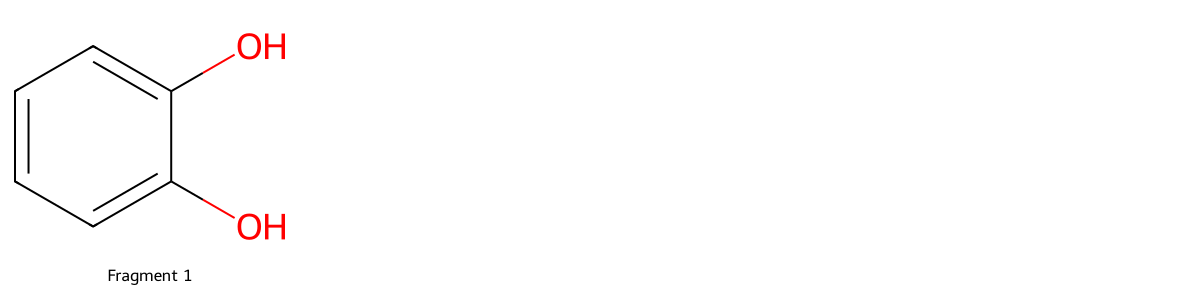

In [7]:
# ========================================
# Input fragments directly (modifiable)
# ========================================
# Separate multiple fragments with '.'
# input_fragments = 'OC1=C(O)C=CC([*])=C1.[*]N[*]' # For brics
# input_fragments = 'OC1=C(O)C=CC([*])=C1' # For brics
# input_fragments = 'OC1=C(C=CC=C1)O.[*]N[*]' # For rc-cms
input_fragments = 'OC1=C(C=CC=C1)O' # For rc-cms

# Validate fragments
frag_list = input_fragments.split('.')
validated = []
for frag in frag_list:
    m = Chem.MolFromSmiles(frag)
    assert m is not None, f'Invalid fragment SMILES: {frag}'
    validated.append(Chem.MolToSmiles(m))

custom_frags = '.'.join(validated)
print(f'Input fragments (canonical): {custom_frags}')
print(f'Number of fragments: {len(validated)}')

draw_mols(validated, legends=[f'Fragment {i+1}' for i in range(len(validated))])

### 6a. T5Chem (RFFMG) Generation from Custom Fragments

**Note**: Run this cell in the `t5chem` environment.

Input fragments: Oc1ccccc1O
Running: t5chem predict --data_dir /tmp/tmpmkr_qpfj --model_dir models/t5chem/trained/rffmg/rc_cms/best_model/ --prediction /tmp/tmpmkr_qpfj/predictions.csv --num_beams 10 --num_preds 10 --batch_size 1


,target,prediction_1,prediction_2,prediction_3,prediction_4,prediction_5,prediction_6,prediction_7,prediction_8,prediction_9,prediction_10,rank
0,C,CCCCc1ccc(O)c(O)c1,CCCCCc1ccc(O)c(O)c1,CCCCCCc1ccc(O)c(O)c1,CCCc1ccc(O)c(O)c1,CCCc1cc(O)c(O)cc1O,CCCCc1cc(O)c(O)cc1O,CCCc1cc(O)c(O)cc1C,CCCCCc1cc(O)c(O)cc1C,O=C(O)c1cc(O)c(O)c([N+](=O)[O-])c1O,O=C(O)c1cc(O)c(O)c(Cl)c1O,0


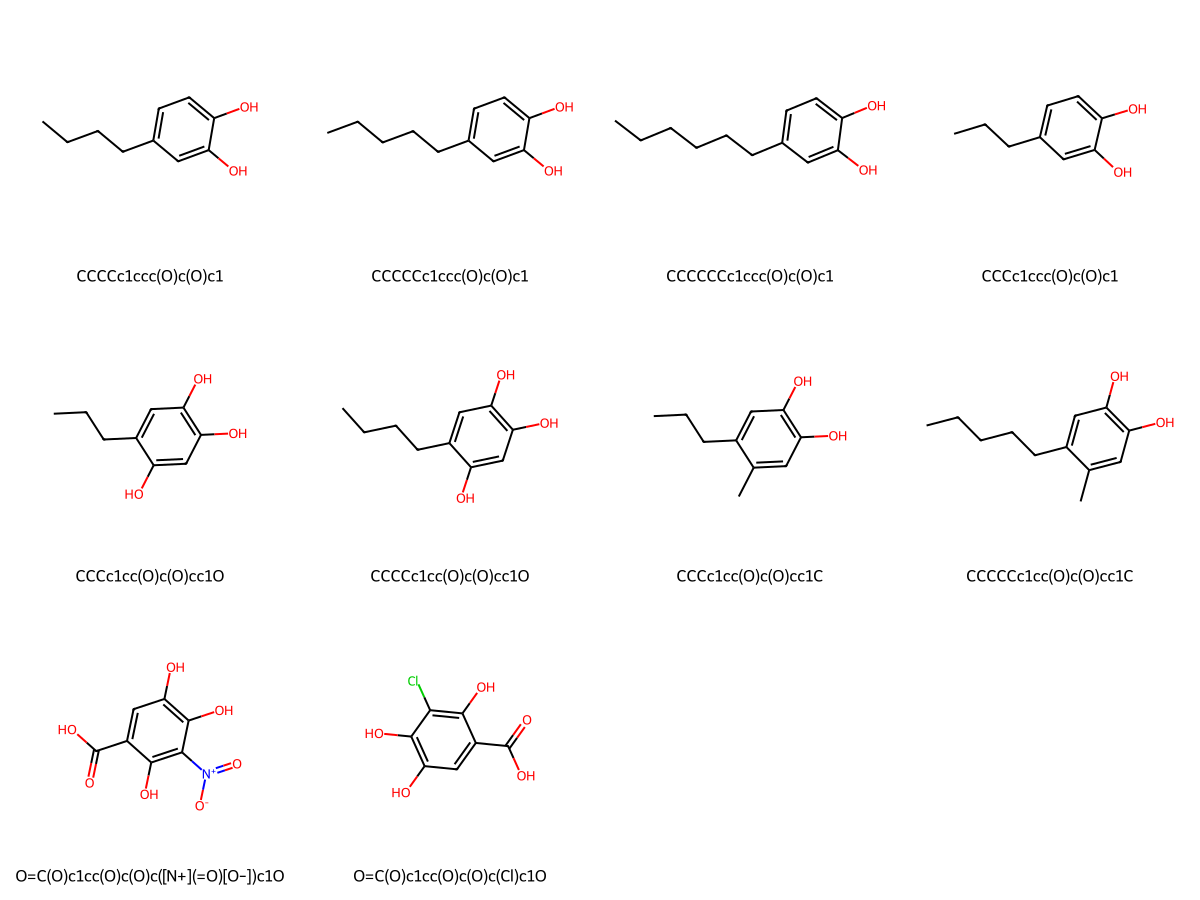

In [8]:
print(f'Input fragments: {custom_frags}')
smiles = generate_t5chem(custom_frags, T5CHEM_MODEL_PATH, NUM_BEAMS, N_SAMPLES)
if smiles:
    draw_mols(smiles)
gen_smiles    = [[custom_frags] + smiles]
gen_smiles_df = pd.DataFrame(gen_smiles, columns=['input'] + [f'top-{k}' for k in range(1, len(smiles)+1)])
os.makedirs(f'results/t5chem/trained/rffmg/{FRAG_METHOD}/custom_frag/', exist_ok=True)
gen_smiles_df.to_csv(f'results/t5chem/trained/rffmg/{FRAG_METHOD}/custom_frag/gen_smiles.csv')


### 6b. SAFE-GPT Generation from Custom Fragments

**Note**: Run this cell in the `safe` environment.

- Single fragment → `scaffold_decoration` (fills attachment points)
- Multiple fragments → `scaffold_morphing` (combines fragments)

Input fragments: *c1ccc(O)c(O)c1.*N*
Multiple fragments -> scaffold morphing


  0%|          | 0/1 [00:00<?, ?it/s]/home/sato/miniconda3/envs/safe/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:649: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
2026-03-17 15:26:25.137 | WARNING  | safe.sample:_completion:893 - I don't think you know what you are doing ... for de novo generation `do_sample=True` or `how='random'` is expected !
2026-03-17 15:26:25.176 | WARNING  | safe.sample:_completion:893 - I don't think you know what you are doing ... for de novo generation `do_sample=True` or `how='random'` is expected !
2026-03-17 15:26:25.241 | WARNING  | safe.sample:_completion:893 - I don't think you know what you are doing ... for de novo generation `do_sample=True` or `how='random'` is expected !
2026-03-17 15:26:25.304 | WARNING  | safe.sample:_completion:893 - I don't think yo

Generated: 8, Valid: 2


,SMILES
0,Cn1nc(-c2ccc(O)c(O)c2)c[n+]1Nc1ccccc1
1,safe_invalid
2,Cn1nc(-c2ccc(O)c(O)c2)c[n+]1Nc1ccccc1
3,safe_invalid
4,safe_invalid
5,safe_invalid
6,safe_invalid
7,safe_invalid


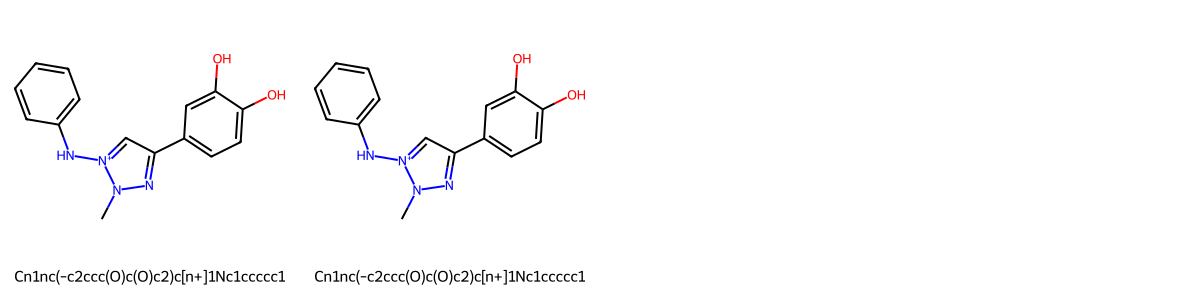

a


In [ ]:
# Load model if not already loaded
if 'safe_generator' not in dir():
    safe_generator = load_safe_model(SAFE_MODEL_PATH)

RANDOM_SEED = 0

print(f'Input fragments: {custom_frags}')
smiles = generate_safe(custom_frags, safe_generator, N_SAMPLES, RANDOM_SEED, MAX_LENGTH)
if smiles:
    draw_mols(smiles)
gen_smiles    = [[custom_frags] + smiles]
gen_smiles_df = pd.DataFrame(gen_smiles, columns=['input'] + [f'top-{k}' for k in range(1, len(smiles)+1)])
os.makedirs(f'results/safe_gpt/trained/rffmg/{FRAG_METHOD}/custom_frag/', exist_ok=True)
gen_smiles_df.to_csv(f'results/safe_gpt/trained/rffmg/{FRAG_METHOD}/custom_frag/gen_smiles.csv')